In [1]:
!pip install gymnasium

In [2]:
import gymnasium as gym
import numpy
import random
import matplotlib.pyplot as plt
import heapq
from itertools import count

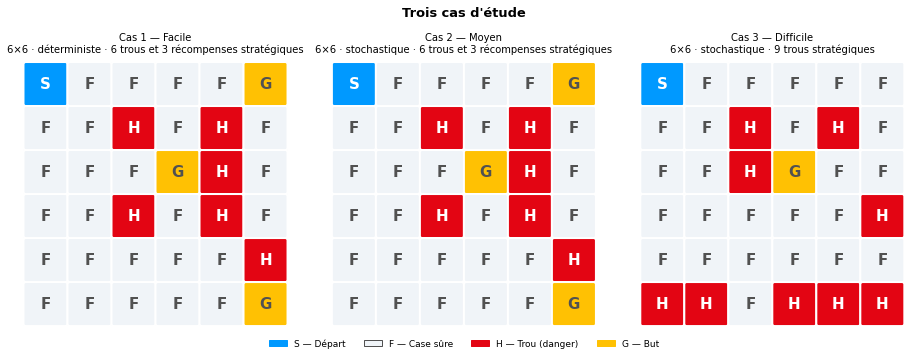

In [3]:
import matplotlib.patches as mpatches

COLORS = ['#e30513', '#ffc103', '#0099ff', '#515151',
          '#f7a941', '#51a27e', '#702e78', '#7b003d']
TILE_COLORS = {'S': COLORS[2], 'F': '#f0f4f8', 'H': COLORS[0], 'G': COLORS[1]}
TILE_TEXT   = {'S': 'white',   'F': COLORS[3], 'H': 'white',   'G': COLORS[3]}

titles = [
    "Cas 1 — Facile\n6×6 · déterministe · 6 trous et 3 récompenses stratégiques",
    "Cas 2 — Moyen\n6×6 · stochastique · 6 trous et 3 récompenses stratégiques",
    "Cas 3 — Difficile\n6×6 · stochastique · 9 trous stratégiques",
]

MAPS = {
    "easy": {
        "desc": ["SFFFFG","FFHFHF", "FFFGHF", "FFHFHF", "FFFFFH", "FFFFFG"],
        "is_slippery": False,
    },
    "medium": {
        "desc": ["SFFFFG","FFHFHF", "FFFGHF", "FFHFHF", "FFFFFH", "FFFFFG"],
        "is_slippery": True,
    },
    "hard": {
        "desc": ["SFFFFF", "FFHFHF", "FFHGFF", "FFFFFH", "FFFFFF", "HHFHHH"],
        "is_slippery": True,
    },
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (name, cfg), title in zip(axes, MAPS.items(), titles):
    desc = cfg['desc']
    nrow, ncol = len(desc), len(desc[0])
    for r, row in enumerate(desc):
        for c, tile in enumerate(row):
            ax.add_patch(mpatches.FancyBboxPatch(
                (c+0.05, nrow-r-1+0.05), 0.9, 0.9,
                boxstyle='round,pad=0.05',
                facecolor=TILE_COLORS[tile], edgecolor='white', linewidth=2))
            ax.text(c+0.5, nrow-r-0.5, tile, ha='center', va='center',
                    fontsize=15, fontweight='bold', color=TILE_TEXT[tile])
    ax.set_xlim(0, ncol); ax.set_ylim(0, nrow)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=10, pad=10)
    
legend = [
    mpatches.Patch(color=TILE_COLORS['S'], label='S — Départ'),
    mpatches.Patch(color=TILE_COLORS['F'], label='F — Case sûre', ec=COLORS[3]),
    mpatches.Patch(color=TILE_COLORS['H'], label='H — Trou (danger)'),
    mpatches.Patch(color=TILE_COLORS['G'], label='G — But'),
]
fig.legend(handles=legend, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.06), frameon=False, fontsize=9)
plt.suptitle("Trois cas d'étude", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
#os.makedirs('figures', exist_ok=True)
#plt.savefig('figures/maps.png', dpi=150, bbox_inches='tight')
plt.show()

# Stratégies d'apprentissage

In [4]:
def set_all_seeds(seed):
    random.seed(seed)
    numpy.random.seed(seed)

In [5]:
# Politique souple comme politique de comportement
def epsilon_greedy(Q, state, epsilon, n_actions):
    if random.random() < epsilon:
        return random.randint(0, n_actions - 1)
    else:
        return numpy.argmax(Q[state])

In [6]:
def q_learning(environment, gamma, learning_rate, max_episodes, seed=None):

    if seed is not None:
        set_all_seeds(seed)
        environment.reset(seed=seed)         
        environment.action_space.seed(seed)
    
    n_states = environment.observation_space.n  
    n_actions = environment.action_space.n

    Q = numpy.random.random((n_states, n_actions))

    episode_rewards = []
    for episode in range(1, max_episodes + 1):

        epsilon = max(0.05, 0.99 ** (episode - 1))
        lr = max(0.01, learning_rate * (0.99 ** (episode - 1)))

        state, _ = environment.reset(seed=seed + episode if seed is not None else None)

        total_reward = 0
        done = False

        while not done:
            action = epsilon_greedy(Q, state, epsilon, n_actions)

            next_state, reward, terminated, truncated, _ = environment.step(action)
            done = terminated or truncated

            q_max = numpy.max(Q[next_state])

            Q[state, action] = Q[state, action] + lr * (  
                reward + gamma * q_max - Q[state, action]
            )

            total_reward += reward
            state = next_state
        
        episode_rewards.append(total_reward)

    return Q, episode_rewards

In [7]:
def sarsa(environment, gamma, learning_rate, max_episodes, seed = None):
    
    if seed is not None:
        set_all_seeds(seed)
        environment.reset(seed=seed)        
        environment.action_space.seed(seed)

    n_states = environment.observation_space.n
    n_actions = environment.action_space.n

    Q = numpy.random.random((n_states, n_actions))

    episode_rewards = []
    for episode in range(1, max_episodes + 1):

        epsilon = max(0.05, 0.99 ** (episode - 1))
        lr = max(0.01, learning_rate * (0.99 ** (episode - 1)))

        state, _ = environment.reset(seed=seed + episode if seed is not None else None)

        action = epsilon_greedy(Q, state, epsilon, n_actions)

        total_reward = 0
        done = False

        while not done:

            next_state, reward, terminated, truncated, _ = environment.step(action)
            done = terminated or truncated

            next_action = epsilon_greedy(Q, next_state, epsilon, n_actions)

            Q[state, action] = Q[state, action] + lr * (
                reward + gamma * Q[next_state, next_action] - Q[state, action]
            )

            total_reward += reward

            state = next_state
            action = next_action

        episode_rewards.append(total_reward)

    return Q, episode_rewards

# Visualisation

In [8]:
# Visualisation d'une politique greedy 
def display_tabular(q_values, desc, max_steps=100):

    environment = gym.make("FrozenLake-v1", desc=desc, is_slippery=True, render_mode="human")

    state, _ = environment.reset()

    terminated, truncated = False, False
    time_step = 0

    while not (terminated or truncated) and time_step < max_steps:
        environment.render()

        action = numpy.argmax(q_values[state])
        print("Chosen action:", action)

        next_state, _, terminated, truncated, _ = environment.step(action)

        state = next_state
        time_step += 1

    environment.close()

In [9]:
# Courbe d'apprentissage moins bruitee
def moving_average(data, window=100):
    return [sum(data[i:i+window])/window for i in range(len(data)-window)]

def moving_average_rewards(data, window=100):
    return numpy.convolve(data, numpy.ones(window)/window, mode='valid')

def plot_smoothed_learning(rewards_list, labels):

    plt.figure()

    for rewards, label in zip(rewards_list, labels):
        smoothed = moving_average(rewards)
        plt.plot(smoothed, label=label)

    plt.title("Courbe d'apprentissage moins bruitée")
    plt.xlabel("Episode")
    plt.ylabel("Récompense")
    plt.legend()
    plt.grid()

    plt.show()

In [10]:
def plot_learning_with_variance(means, stds, labels, strategy):

    plt.figure()

    for mean, std, label in zip(means, stds, labels):

        x = range(len(mean))

        plt.plot(x, mean, label=label)

        plt.fill_between(
            x,
            mean - std,
            mean + std,
            alpha=0.2
        )

    plt.title(f"Courbes d'apprentissage - {strategy}")
    plt.xlabel("Episode")
    plt.ylabel("Récompense cumulée (moyenne mobile)")
    plt.legend()
    plt.grid()

    plt.show()

# Personnalisation de l'environnement FrozenLake-v1

In [11]:
class CustomFrozenLake(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.nrow = env.unwrapped.nrow
        self.ncol = env.unwrapped.ncol
        self.desc = env.unwrapped.desc
        self.visited_states = set()

    def reset(self, **kwargs):
        state, info = self.env.reset(**kwargs)
        self.visited_states = set()
        self.visited_states.add(state) 
        return state, info

    def step(self, action):
        current_state = self.env.unwrapped.s

        next_state, _, terminated, truncated, info = self.env.step(action)

        row, col = divmod(next_state, self.ncol)
        tile = self.desc[row][col].decode("utf-8")

        if tile == 'H': # H correspond à un trou
            reward = -1

        elif tile == 'G': # G correspond à un cadeau
            reward = 1

        elif next_state == current_state: # ceci traite le cas où l'agent sort de la grille
            reward = -0.1

        #elif next_state in self.visited_states: # ceci traite le cas où l'agent revient à des états qui a déja visité
         #   reward = -2   t

        else:
            reward = 0

        self.visited_states.add(next_state)

        return next_state, reward, terminated, truncated, info

# Environnement simple

In [12]:
#safe_map = [
#    "SFFH",
#    "FFFH",
#    "FFGF",
#    "FFHF"
#]
safe_map = [
    "SFFFFG",
    "FFHFHF",
    "FFFGHF",
    "FFHFHF",
    "FFFFFH",
    "FFFFFG"
]

safe_env = gym.make("FrozenLake-v1", desc=safe_map, is_slippery=False)
safe_env = CustomFrozenLake(safe_env)

### a- Q-learning

In [13]:
n_runs = 10
seeds = [1000 * i + 1 for i in range(n_runs)]

gamma = 0.99 
learning_rate = 0.5
max_episodes = 1000

qValues_qLearning_safeMap_list = []
rewards_qLearning_safeMap = []

for s in seeds:
    qValues, rewards = q_learning(safe_env, gamma, learning_rate, max_episodes, s)
    
    qValues_qLearning_safeMap_list.append(qValues)
    rewards_qLearning_safeMap.append(rewards)

In [14]:
rewards_qLearning_safeMap = numpy.array(rewards_qLearning_safeMap)

mean_rewards_qLearning_safeMap= numpy.mean(rewards_qLearning_safeMap, axis=0)
std_rewards_qLearning_safeMap = numpy.std(rewards_qLearning_safeMap, axis=0)

mean_rewards_qLearning_safeMap= moving_average_rewards(mean_rewards_qLearning_safeMap)
std_rewards_qLearning_safeMap = moving_average_rewards(std_rewards_qLearning_safeMap)

In [15]:
display_tabular(qValues_qLearning_safeMap_list[0], safe_map)

Chosen action: 1
Chosen action: 1
Chosen action: 1
Chosen action: 2
Chosen action: 2


### b- Sarsa

In [16]:
gamma = 0.99
learning_rate = 0.5
max_episodes = 1000

qValues_sarsa_safeMap_list = []
rewards_sarsa_safeMap = []

for s in seeds:
    qValues, rewards = sarsa(safe_env, gamma, learning_rate, max_episodes, s)
    
    qValues_sarsa_safeMap_list.append(qValues)
    rewards_sarsa_safeMap.append(rewards)

In [17]:
rewards_sarsa_safeMap = numpy.array(rewards_sarsa_safeMap)

mean_rewards_sarsa_safeMap= numpy.mean(rewards_sarsa_safeMap, axis=0)
std_rewards_sarsa_safeMap = numpy.std(rewards_sarsa_safeMap, axis=0)

mean_rewards_sarsa_safeMap= moving_average_rewards(mean_rewards_sarsa_safeMap)
std_rewards_sarsa_safeMap = moving_average_rewards(std_rewards_sarsa_safeMap)

In [18]:
display_tabular(qValues_sarsa_safeMap_list[0], safe_map)

Chosen action: 2
Chosen action: 1
Chosen action: 2
Chosen action: 1
Chosen action: 1


# Premier Environnement difficile

In [19]:
hard_map1 = [
    "SFFFFG",
    "FFHFHF",
    "FFFGHF",
    "FFHFHF",
    "FFFFFH",
    "FFFFFG"
]

hard_env1 = gym.make("FrozenLake-v1", desc=hard_map1, is_slippery=True)
hard_env1 = CustomFrozenLake(hard_env1)

### a- Q-learning

In [20]:
gamma = 0.99
learning_rate = 0.5
max_episodes = 1000

qValues_qLearning_hardMap1_list = []
rewards_qLearning_hardMap1 = []

for s in seeds:
    qValues, rewards = q_learning(hard_env1, gamma, learning_rate, max_episodes, s)
    
    qValues_qLearning_hardMap1_list.append(qValues)
    rewards_qLearning_hardMap1.append(rewards)

In [21]:
rewards_qLearning_hardMap1 = numpy.array(rewards_qLearning_hardMap1)

mean_rewards_qLearning_hardMap1= numpy.mean(rewards_qLearning_hardMap1, axis=0)
std_rewards_qLearning_hardMap1 = numpy.std(rewards_qLearning_hardMap1, axis=0)

mean_rewards_qLearning_hardMap1 = moving_average_rewards(mean_rewards_qLearning_hardMap1)
std_rewards_qLearning_hardMap1 = moving_average_rewards(std_rewards_qLearning_hardMap1)

In [22]:
display_tabular(qValues_qLearning_hardMap1_list[0], hard_map1)

Chosen action: 2
Chosen action: 2
Chosen action: 2
Chosen action: 2
Chosen action: 0
Chosen action: 1
Chosen action: 0
Chosen action: 2
Chosen action: 0
Chosen action: 1
Chosen action: 0
Chosen action: 2
Chosen action: 2
Chosen action: 2
Chosen action: 0
Chosen action: 2
Chosen action: 0
Chosen action: 2
Chosen action: 3
Chosen action: 2
Chosen action: 0
Chosen action: 2
Chosen action: 3
Chosen action: 2
Chosen action: 0
Chosen action: 3
Chosen action: 2
Chosen action: 1
Chosen action: 2
Chosen action: 3
Chosen action: 1
Chosen action: 3
Chosen action: 1
Chosen action: 3
Chosen action: 2
Chosen action: 1
Chosen action: 0
Chosen action: 1
Chosen action: 0
Chosen action: 1
Chosen action: 2
Chosen action: 1
Chosen action: 0
Chosen action: 2
Chosen action: 0
Chosen action: 2
Chosen action: 0
Chosen action: 3
Chosen action: 1
Chosen action: 3
Chosen action: 1
Chosen action: 3
Chosen action: 3
Chosen action: 0
Chosen action: 2


### b- Sarsa

In [23]:
gamma = 0.99
learning_rate = 0.5
max_episodes = 1000

qValues_sarsa_hardMap1_list = []
rewards_sarsa_hardMap1 = []

for s in seeds:
    qValues, rewards = sarsa(hard_env1, gamma, learning_rate, max_episodes, s)
    
    qValues_sarsa_hardMap1_list.append(qValues)
    rewards_sarsa_hardMap1.append(rewards)

In [24]:
rewards_sarsa_hardMap1 = numpy.array(rewards_sarsa_hardMap1)

mean_rewards_sarsa_hardMap1= numpy.mean(rewards_sarsa_hardMap1, axis=0)
std_rewards_sarsa_hardMap1 = numpy.std(rewards_sarsa_hardMap1, axis=0)

mean_rewards_sarsa_hardMap1 = moving_average_rewards(mean_rewards_sarsa_hardMap1)
std_rewards_sarsa_hardMap1 = moving_average_rewards(std_rewards_sarsa_hardMap1)

In [25]:
display_tabular(qValues_sarsa_hardMap1_list[0], hard_map1)

Chosen action: 2
Chosen action: 2
Chosen action: 2
Chosen action: 0
Chosen action: 1
Chosen action: 3
Chosen action: 3
Chosen action: 1
Chosen action: 3
Chosen action: 3
Chosen action: 2
Chosen action: 3
Chosen action: 3


# Deuxième environnement difficile

In [26]:
hard_map2 = [
    "SFFFFF",
    "FFHFHF",
    "FFHGFF",
    "FFFFFH",
    "FFFFFF",
    "HHFHHH"
]

hard_env2 = gym.make("FrozenLake-v1", desc=hard_map2, is_slippery=True)
hard_env2 = CustomFrozenLake(hard_env2)

### a- Q-learning

In [27]:
gamma = 0.99
learning_rate = 0.5
max_episodes = 1000

qValues_qLearning_hardMap2_list = []
rewards_qLearning_hardMap2 = []

for s in seeds:
    qValues, rewards = q_learning(hard_env2, gamma, learning_rate, max_episodes, s)
    
    qValues_qLearning_hardMap2_list.append(qValues)
    rewards_qLearning_hardMap2.append(rewards)

In [28]:
rewards_qLearning_hardMap2 = numpy.array(rewards_qLearning_hardMap2)

mean_rewards_qLearning_hardMap2= numpy.mean(rewards_qLearning_hardMap2, axis=0)
std_rewards_qLearning_hardMap2 = numpy.std(rewards_qLearning_hardMap2, axis=0)

mean_rewards_qLearning_hardMap2 = moving_average_rewards(mean_rewards_qLearning_hardMap2)
std_rewards_qLearning_hardMap2 = moving_average_rewards(std_rewards_qLearning_hardMap2)

In [29]:
display_tabular(qValues_qLearning_hardMap2_list[0], hard_map2)

Chosen action: 2
Chosen action: 2
Chosen action: 2
Chosen action: 3
Chosen action: 1
Chosen action: 1
Chosen action: 3
Chosen action: 1
Chosen action: 1
Chosen action: 3
Chosen action: 3
Chosen action: 1
Chosen action: 2


### b- Sarsa

In [30]:
gamma = 0.99
learning_rate = 0.5
max_episodes = 1000

qValues_sarsa_hardMap2_list = []
rewards_sarsa_hardMap2 = []

for s in seeds:
    qValues, rewards = sarsa(hard_env2, gamma, learning_rate, max_episodes, s)
    
    qValues_sarsa_hardMap2_list.append(qValues)
    rewards_sarsa_hardMap2.append(rewards)

In [31]:
rewards_sarsa_hardMap2 = numpy.array(rewards_sarsa_hardMap2)

mean_rewards_sarsa_hardMap2= numpy.mean(rewards_sarsa_hardMap2, axis=0)
std_rewards_sarsa_hardMap2 = numpy.std(rewards_sarsa_hardMap2, axis=0)

mean_rewards_sarsa_hardMap2 = moving_average_rewards(mean_rewards_sarsa_hardMap2)
std_rewards_sarsa_hardMap2 = moving_average_rewards(std_rewards_sarsa_hardMap2)

In [32]:
display_tabular(qValues_sarsa_hardMap2_list[0], hard_map2)

Chosen action: 2
Chosen action: 2
Chosen action: 1
Chosen action: 2
Chosen action: 2
Chosen action: 0
Chosen action: 0
Chosen action: 1
Chosen action: 3
Chosen action: 3
Chosen action: 3
Chosen action: 1
Chosen action: 3
Chosen action: 3
Chosen action: 3
Chosen action: 3
Chosen action: 3
Chosen action: 1
Chosen action: 3
Chosen action: 2
Chosen action: 1


# Evaluation des résultats

In [33]:
# Cette fonction permet de determiner si l'agent se trouve dans une situation dangereuse ou non
def is_dangerous(desc, row, col):

    nrow = len(desc)
    ncol = len(desc[0])

    directions = [
        (-1, 0),  # haut
        (1, 0),   # bas
        (0, -1),  # gauche
        (0, 1)    # droite
    ]

    for dr, dc in directions:
        r, c = row + dr, col + dc

        if 0 <= r < nrow and 0 <= c < ncol:
            if desc[r][c].decode("utf-8") == 'H':
                return True

    return False

In [34]:
# Cette fonction permet de collecter un ensemble de métriques pour évaluer la performance de l'agent sur un ensemble d'épisodes
def evaluate_policy(env, Q, seed=None, n_episodes=500, max_steps=100):
    
    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)

    ncol = env.unwrapped.ncol
    desc = env.unwrapped.desc

    success = 0
    falls = 0
    wall_hits = 0
    danger_states = 0
    total_steps = 0
    episodes_steps = []
    episodes_wall_hits = []
    episodes_danger_states = []

    for episode in range(n_episodes):

        state, _ = env.reset(seed=seed + episode if seed is not None else None)
        done = False
        episode_step = 0
        episode_wall_hits = 0
        episode_danger_states = 0

        for step in range(max_steps):
            total_steps +=1
            episode_step += 1
            
            action = numpy.argmax(Q[state])

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # coordonnées
            row, col = divmod(next_state, ncol)
            tile = desc[row][col].decode("utf-8")

            if tile == 'G':
                success += 1

            elif tile == 'H':
                falls += 1

            if next_state == state:
                wall_hits += 1
                episode_wall_hits +=1

            if is_dangerous(desc, row, col):
                danger_states += 1
                episode_danger_states += 1

            state = next_state

            if done:
                break
        episodes_steps.append(episode_step)
        episodes_wall_hits.append(episode_wall_hits)
        episodes_danger_states.append(episode_danger_states)

    avg_steps = sum(episodes_steps) / n_episodes
    avg_wall_hits = sum(episodes_wall_hits) / n_episodes
    avg_danger_states = sum(episodes_danger_states) / n_episodes
    loops = n_episodes - success - falls
    wall_hits_per_cent = wall_hits / total_steps
    danger_states_per_cent = danger_states / total_steps
    
    #print("Success : ",success, "; Falls : ", falls, "; Loops : ", loops, ".\n")
    
    return {
        "average steps": avg_steps,
        "success": success,
        "falls": falls,
        "loops": loops,
        "wall_hits": wall_hits,
        "wall_hits%": wall_hits_per_cent,
        "average wall hits per episode": avg_wall_hits,
        "danger_states": danger_states,
        "danger_states%": danger_states_per_cent,
        "average danger states per episode": avg_danger_states,
        
        "episodes_steps": episodes_steps,
        "episodes_wall_hits": episodes_wall_hits,
        "episodes_danger_states": episodes_danger_states,
    }

In [35]:
def evaluate_policy_multiple_times(env, Q, seeds, n_episodes=500):

    success_rates = []
    fall_rates = []
    loop_rates = []

    episodes_steps_all = []
    episodes_wall_hits_all = []
    episodes_danger_states_all = []

    for seed in seeds:

        metrics = evaluate_policy(env, Q, seed, n_episodes=n_episodes)

        success_rates.append(metrics["success"] / n_episodes)
        fall_rates.append(metrics["falls"] / n_episodes)
        loop_rates.append(metrics["loops"] / n_episodes)

        episodes_steps_all.extend(metrics["episodes_steps"])
        episodes_wall_hits_all.extend(metrics["episodes_wall_hits"])
        episodes_danger_states_all.extend(metrics["episodes_danger_states"])

    return {
        "success_mean": numpy.mean(success_rates),
        "success_std": numpy.std(success_rates),

        "fall_mean": numpy.mean(fall_rates),
        "fall_std": numpy.std(fall_rates),

        "loop_mean": numpy.mean(loop_rates),
        "loop_std": numpy.std(loop_rates),

        "episodes_steps": episodes_steps_all,
        "episodes_wall_hits": episodes_wall_hits_all,
        "episodes_danger_states": episodes_danger_states_all,
    }

In [36]:
def print_policy_stats(stats, name="Policy"):

    print(f"\n{name}")
    print("=" * len(name))

    print(f"{'Metric':<10} {'Mean':>8} {'Std':>8}")
    print("-" * 28)

    print(f"{'Success':<10} {stats['success_mean']:>8.3f} {stats['success_std']:>8.3f}")
    print(f"{'Falls':<10}   {stats['fall_mean']:>8.3f} {stats['fall_std']:>8.3f}")
    print(f"{'Loops':<10}   {stats['loop_mean']:>8.3f} {stats['loop_std']:>8.3f}")

In [37]:
def get_neighbors(state):
    r, c = divmod(state, ncol)
    moves = [(r-1, c), (r+1, c), (r, c-1), (r, c+1)]
    neighbors = []
    for nr, nc_ in moves:
        if 0 <= nr < nrow and 0 <= nc_ < ncol:
            neighbors.append(nr * ncol + nc_)
    return neighbors

def safest_path(env, danger_penalty=3):
    desc = env.unwrapped.desc
    nrow, ncol = desc.shape
    start = None
    goals = []

    for r in range(nrow):
        for c in range(ncol):
            if desc[r][c] == b'S':
                start = r * ncol + c
            elif desc[r][c] == b'G':
                goals.append(r * ncol + c)


    tiebreak = count()
    pq = [(0, next(tiebreak), start, [])]
    best_cost_at = {}
    best_path = None
    best_cost = float('inf')

    while pq:
        cost, _, state, path = heapq.heappop(pq)

        if cost >= best_cost_at.get(state, float('inf')):
            continue
        best_cost_at[state] = cost

        if cost >= best_cost:
            continue

        path = path + [state]

        if state in goals:
            if cost < best_cost:
                best_cost = cost
                best_path = path
            continue

        for next_state in get_neighbors(state):
            r, c = divmod(next_state, ncol)
            tile = desc[r][c].decode("utf-8")

            if tile == 'H':
                continue

            step_cost = danger_penalty if is_dangerous(desc, r, c) else 0

            new_cost = cost + step_cost
            if new_cost < best_cost_at.get(next_state, float('inf')):
                heapq.heappush(pq, (new_cost, next(tiebreak), next_state, path))

    return best_path, best_cost

In [38]:
def classify_paths(success_paths, safe_path, tolerance=0.7):

    safe_set = set(safe_path)

    safe_count = 0
    risky_count = 0

    for path in success_paths:

        overlap = sum(1 for s in path if s in safe_set)
        ratio = overlap / len(path)

        if ratio >= tolerance:
            safe_count += 1
        else:
            risky_count += 1

    return safe_count, risky_count

In [39]:
def evaluate_success_paths(env, Q, seed=None, n_episodes=500, max_steps=100):
    
    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)

    ncol = env.unwrapped.ncol
    desc = env.unwrapped.desc

    success_paths = []

    for episode in range(n_episodes):

        state, _ = env.reset(seed=seed + episode if seed is not None else None)
        path = [state]

        for _ in range(max_steps):

            action = numpy.argmax(Q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)

            path.append(next_state)

            row, col = divmod(next_state, ncol)
            tile = desc[row][col].decode("utf-8")

            if tile == 'G':
                success_paths.append(path)
                break

            if terminated or truncated:
                break

            state = next_state

    return success_paths

def evaluate_safe_path_rate_multiple(env, Q, seeds, n_episodes=1000, max_steps=100):
    safe_rates = []
    safe_path, _ = safest_path(env)

    for seed in seeds:
        success_paths = evaluate_success_paths(env, Q, seed=seed, n_episodes=n_episodes, max_steps=max_steps)
        
        n_safe, _ = classify_paths(success_paths, safe_path)

        safe_rate = n_safe / len(success_paths)
        safe_rates.append(safe_rate)

    stats = {
        "mean":     numpy.mean(safe_rates),
        "std":      numpy.std(safe_rates),
        "min":      numpy.min(safe_rates),
        "max":      numpy.max(safe_rates),
    }
    return stats



### a- Environnement simple

#### i- Q-learning

In [40]:
easy_env_evaluations_q = []
n_eval_runs = 10
eval_seeds = [500 * i + 1 for i in range(20, 20 + n_eval_runs)]

for Q in qValues_qLearning_safeMap_list:
    metrics = evaluate_policy_multiple_times(safe_env, Q, eval_seeds)
    easy_env_evaluations_q.append(metrics)

best_index_q1 = max(range(len(easy_env_evaluations_q)), key=lambda i: easy_env_evaluations_q[i]["success_mean"])

best_qValues_qLearning_safeMap = qValues_qLearning_safeMap_list[best_index_q1]

In [41]:
q_res_env1 = evaluate_policy_multiple_times(safe_env, best_qValues_qLearning_safeMap, eval_seeds)

print_policy_stats(q_res_env1, "Q-learning (Safe Env)")


Q-learning (Safe Env)
Metric         Mean      Std
----------------------------
Success       1.000    0.000
Falls           0.000    0.000
Loops           0.000    0.000


#### ii- Sarsa

In [42]:
easy_env_evaluations_s = []

for Q in qValues_sarsa_safeMap_list:
    metrics = evaluate_policy_multiple_times(safe_env, Q, eval_seeds)
    easy_env_evaluations_s.append(metrics)

best_index_s1 = max(range(len(easy_env_evaluations_s)), key=lambda i: easy_env_evaluations_s[i]["success_mean"])

best_qValues_sarsa_safeMap = qValues_sarsa_safeMap_list[best_index_s1]

In [43]:
sarsa_res_env1 = evaluate_policy_multiple_times(safe_env, best_qValues_sarsa_safeMap, eval_seeds)

print_policy_stats(sarsa_res_env1, "Sarsa (Safe Env)")


Sarsa (Safe Env)
Metric         Mean      Std
----------------------------
Success       1.000    0.000
Falls           0.000    0.000
Loops           0.000    0.000


### b- Premier envirronement difficile

In [44]:
def get_goal_states(desc):
    nrow = len(desc)
    ncol = len(desc[0])
    
    goal_states = {}
    
    for r in range(nrow):
        for c in range(ncol):
            if desc[r][c] == 'G':
                state = r * ncol + c
                goal_states[state] = (r, c)
    
    return goal_states

In [45]:
# Fonction pour savoir le nombre de fois ou l'agent a converge a chaque cadeau different
def evaluate_goals(env, Q, seed=None, n_episodes=500, max_steps=100):
    
    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
        
    desc = ["".join(row) for row in env.unwrapped.desc.astype(str)]
    ncol = env.unwrapped.ncol

    goal_states = get_goal_states(desc)
    goal_counts = {state: 0 for state in goal_states}
    successful_episodes = 0

    for episode in range(n_episodes):
        state, _ = env.reset(seed=seed + episode if seed is not None else None)
        reached_goal = None

        for step in range(max_steps):
            action = numpy.argmax(Q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            state = next_state

            if terminated or truncated:
                if state in goal_counts:
                    reached_goal = state
                break

        if reached_goal is not None:
            goal_counts[reached_goal] += 1
            successful_episodes += 1

    if successful_episodes > 0:
        goal_rates = {g: count / successful_episodes for g, count in goal_counts.items()}
    else:
        goal_rates = {g: 0 for g in goal_counts}

    return goal_rates

def evaluate_goals_multiple(env, Q, seeds, n_runs=10, n_episodes=500):

    ncol = env.unwrapped.ncol

    all_results = []

    for seed in seeds:
        goal_rates = evaluate_goals(env, Q, seed, n_episodes)
        all_results.append(goal_rates)

    goals = all_results[0].keys()

    stats = {}

    for g in goals:
        values = [run[g] for run in all_results]

        coord = divmod(g, ncol)

        stats[coord] = {
            "mean": numpy.mean(values),
            "std": numpy.std(values)
        }

    return stats

In [46]:
def plot_goal_distribution(stats, strategy):

    coords = list(stats.keys())
    means = [stats[c]["mean"] for c in coords]
    stds = [stats[c]["std"] for c in coords]

    labels = [f"{c}" for c in coords]

    plt.figure()
    plt.bar(labels, means, yerr=stds)

    plt.xlabel("Coordonnées de la récompense")
    plt.ylabel("Ratio moyen")
    plt.title(f"Ratio moyen de convergence vers chaque récompense - {strategy}")
    plt.xticks(rotation=45)
    plt.grid()

    plt.show()

#### i- Q-learning

In [47]:
hard_env1_evaluations_q = []

for Q in qValues_qLearning_hardMap1_list:
    metrics = evaluate_policy_multiple_times(hard_env1, Q, eval_seeds)
    hard_env1_evaluations_q.append(metrics)

best_index_q2 = max(range(len(hard_env1_evaluations_q)), key=lambda i: hard_env1_evaluations_q[i]["success_mean"])

best_qValues_qLearning_hardMap1 = qValues_qLearning_hardMap1_list[best_index_q2]

In [48]:
q_res_env2 = evaluate_policy_multiple_times(hard_env1, best_qValues_qLearning_hardMap1, eval_seeds)

print_policy_stats(q_res_env2, "Q-learning (Medium Env)")


Q-learning (Medium Env)
Metric         Mean      Std
----------------------------
Success       0.600    0.025
Falls           0.399    0.025
Loops           0.001    0.001


In [49]:
q_goal_stats = evaluate_goals_multiple(hard_env1, best_qValues_qLearning_hardMap1, eval_seeds)

for coord, s in q_goal_stats.items():
    print(f"Goal {coord}: {s['mean']:.3f} ± {s['std']:.3f}")

Goal (0, 5): 0.379 ± 0.023
Goal (2, 3): 0.551 ± 0.025
Goal (5, 5): 0.070 ± 0.025


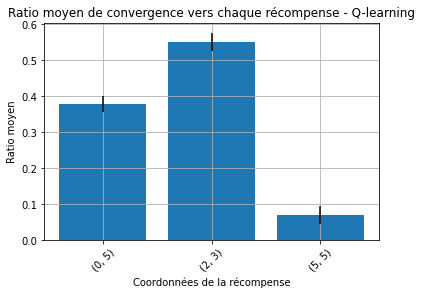

In [50]:
plot_goal_distribution(q_goal_stats, "Q-learning")

#### ii- Sarsa

In [51]:
hard_env1_evaluations_s = []

for Q in qValues_sarsa_hardMap1_list:
    metrics = evaluate_policy_multiple_times(hard_env1, Q, eval_seeds)
    hard_env1_evaluations_s.append(metrics)

best_index_s2 = max(range(len(hard_env1_evaluations_s)), key=lambda i: hard_env1_evaluations_s[i]["success_mean"])

best_qValues_sarsa_hardMap1 = qValues_sarsa_hardMap1_list[best_index_s2]

In [52]:
sarsa_res_env2 = evaluate_policy_multiple_times(hard_env1, best_qValues_sarsa_hardMap1, eval_seeds)

#safe_path, _ = safest_path(hard_env1)
#print(safe_path)

print_policy_stats(sarsa_res_env2, "Sarsa (Medium Env)")


Sarsa (Medium Env)
Metric         Mean      Std
----------------------------
Success       0.600    0.024
Falls           0.389    0.023
Loops           0.011    0.004


In [53]:
sarsa_goal_stats = evaluate_goals_multiple(hard_env1, best_qValues_sarsa_hardMap1, eval_seeds)

for coord, s in sarsa_goal_stats.items():
    print(f"Goal {coord}: {s['mean']:.3f} ± {s['std']:.3f}")

Goal (0, 5): 0.251 ± 0.023
Goal (2, 3): 0.608 ± 0.027
Goal (5, 5): 0.142 ± 0.017


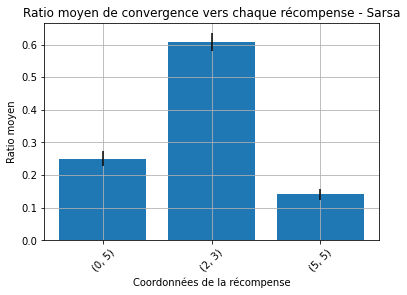

In [54]:
plot_goal_distribution(sarsa_goal_stats, "Sarsa")

### Deuxième environnement difficile

#### i- Q-learning

In [55]:
hard_env2_evaluations_q = []

for Q in qValues_qLearning_hardMap2_list:
    metrics = evaluate_policy_multiple_times(hard_env2, Q, eval_seeds)
    hard_env2_evaluations_q.append(metrics)

best_index_q3 = max(range(len(hard_env2_evaluations_q)), key=lambda i: hard_env2_evaluations_q[i]["success_mean"])

best_qValues_qLearning_hardMap2 = qValues_qLearning_hardMap2_list[best_index_q3]

In [56]:
q_res_env3 = evaluate_policy_multiple_times(hard_env2, best_qValues_qLearning_hardMap2, eval_seeds)

print_policy_stats(q_res_env3, "Q-learning (Hard Env)")


Q-learning (Hard Env)
Metric         Mean      Std
----------------------------
Success       0.652    0.024
Falls           0.277    0.018
Loops           0.071    0.012


In [57]:
path_stats_q = evaluate_safe_path_rate_multiple(hard_env2, best_qValues_qLearning_hardMap2, eval_seeds)

#safe_path, _ = safest_path(hard_env2)

print(f"Ratio moyen des chemins securisés: {path_stats_q['mean']:.3f} ± {path_stats_q['std']:.3f}")

#print(safe_path)

Ratio moyen des chemins securisés: 0.073 ± 0.010


#### ii- Sarsa

In [58]:
hard_env2_evaluations_s = []

for Q in qValues_sarsa_hardMap2_list:
    metrics = evaluate_policy_multiple_times(hard_env2, Q, eval_seeds)
    hard_env2_evaluations_s.append(metrics)

best_index_s3 = max(range(len(hard_env2_evaluations_s)), key=lambda i: hard_env2_evaluations_s[i]["success_mean"])

best_qValues_sarsa_hardMap2 = qValues_sarsa_hardMap2_list[best_index_s3]

In [59]:
sarsa_res_env3 = evaluate_policy_multiple_times(hard_env2, best_qValues_sarsa_hardMap2, eval_seeds)

print_policy_stats(sarsa_res_env3, "Sarsa (Hard Env)")


Sarsa (Hard Env)
Metric         Mean      Std
----------------------------
Success       0.697    0.023
Falls           0.259    0.022
Loops           0.044    0.008


In [60]:
path_stats_sarsa = evaluate_safe_path_rate_multiple(hard_env2, best_qValues_sarsa_hardMap2, eval_seeds)

#safe_path, cost = safest_path(hard_env2)

print(f"Ratio moyen des chemins securisés: {path_stats_sarsa['mean']:.3f} ± {path_stats_sarsa['std']:.3f}")

#print(safe_path)

Ratio moyen des chemins securisés: 0.078 ± 0.013


# Comparaison

In [61]:
def plot_boxplot(results, labels, key, title):

    data = [r[key] for r in results]

    plt.figure()
    plt.boxplot(data, labels=labels)

    plt.title(title)
    plt.xlabel("Environnement")
    plt.ylabel("Valeur")
    plt.grid()

    plt.show()

### Q-learning

In [62]:
results = [q_res_env2, q_res_env3]
rewards_list = [rewards_qLearning_safeMap[best_index_q1], rewards_qLearning_hardMap1[best_index_q2], rewards_qLearning_hardMap2[best_index_q3]]

means = [mean_rewards_qLearning_safeMap, mean_rewards_qLearning_hardMap1, mean_rewards_qLearning_hardMap2]
stds = [std_rewards_qLearning_safeMap, std_rewards_qLearning_hardMap1, std_rewards_qLearning_hardMap2]

labels = ["Facile", "Moyen", "Difficile"]
hard_labels = ["Moyen", "Difficile"]

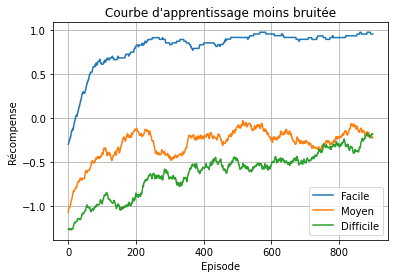

In [63]:
plot_smoothed_learning(rewards_list, labels)

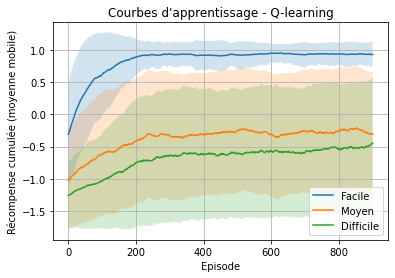

In [64]:
plot_learning_with_variance(means, stds, labels, "Q-learning")

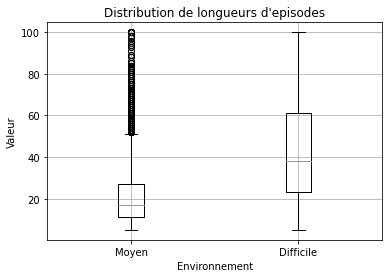

In [65]:
plot_boxplot(results, hard_labels, "episodes_steps", "Distribution de longueurs d'episodes")

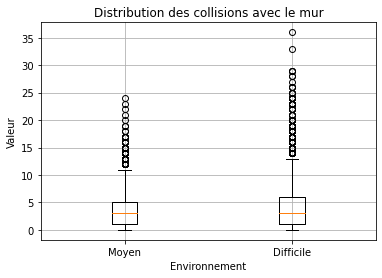

In [66]:
plot_boxplot(results, hard_labels, "episodes_wall_hits", "Distribution des collisions avec le mur")

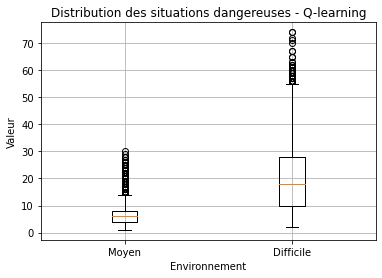

In [67]:
plot_boxplot(results, hard_labels, "episodes_danger_states", "Distribution des situations dangereuses - Q-learning")

### Sarsa

In [68]:
sarsa_results = [sarsa_res_env2, sarsa_res_env3]
sarsa_rewards_list = [rewards_sarsa_safeMap[best_index_s1], rewards_sarsa_hardMap1[best_index_s2], rewards_sarsa_hardMap2[best_index_s3]]

means_s = [mean_rewards_sarsa_safeMap, mean_rewards_sarsa_hardMap1, mean_rewards_sarsa_hardMap2]
stds_s = [std_rewards_sarsa_safeMap, std_rewards_sarsa_hardMap1, std_rewards_sarsa_hardMap2]

labels = ["Facile", "Moyen", "Difficile"]
hard_labels = ["Moyen", "Difficile"]

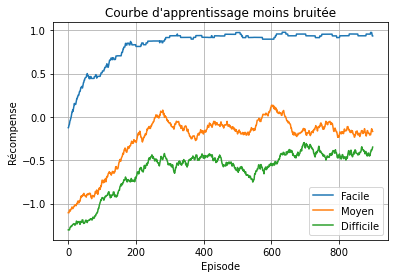

In [69]:
plot_smoothed_learning(sarsa_rewards_list, labels)

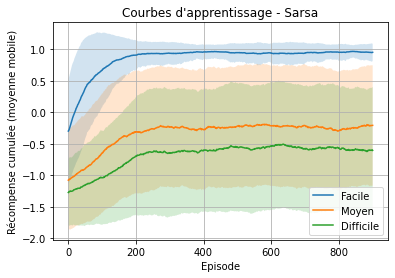

In [70]:
plot_learning_with_variance(means_s, stds_s, labels, "Sarsa")

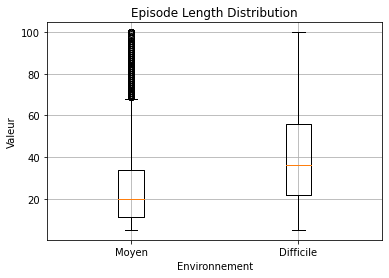

In [71]:
plot_boxplot(sarsa_results, hard_labels, "episodes_steps", "Episode Length Distribution")

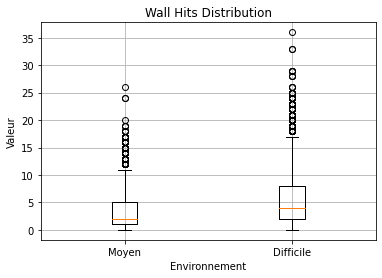

In [72]:
plot_boxplot(sarsa_results, hard_labels, "episodes_wall_hits", "Wall Hits Distribution") # probabelement, il ne porte aucune information

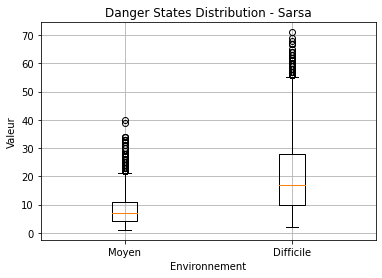

In [73]:
plot_boxplot(sarsa_results, hard_labels, "episodes_danger_states", "Danger States Distribution - Sarsa")